# Universidad de Buenos Aires
## Laboratorio de Sistemas Embebidos
### Especialización en Inteligencia Artificial
#### Análisis de Series de Tiempo 1
**Docente**: Camilo Argoty

**Alumnos**:

- Gaspar Acevedo Zain (código a2101).
- Rodrigo Lauro (código aXXXX).

**Códigos**:

- a2101
- aXXXX

**Fecha**: 15/06/2026

---

# Trabajo Práctico Final — Notebook 3

## SARIMA y SARIMAX — Volumen de tráfico I-94

**Dataset:** Metro Interstate Traffic Volume (UCI)  
**Variable objetivo:** `traffic_volume` (vehículos/hora)  
**Subperiodo:** 2016-01-01 a 2017-12-31  
**Estacionalidad principal:** s = 24 (ciclo diario)  
**Entrada:** artefactos de NB1 (`dataset/processed/`) y NB2 (`dataset/results/`)  
**Umbral baseline (NB2):** Holt-Winters amortiguado — RMSE ≈ **1803.7** veh/h (MAE ≈ 1512.7)

## 3.1 - Setup y carga

En esta sección se importan librerías, se configuran rutas y se cargan los artefactos generados en NB1 y NB2.

**Motivación:** NB3 modela la autocorrelación estocástica que los baselines ETS no capturan por completo. Se reutiliza la partición train/test y las órdenes SARIMA propuestas tras ACF/PACF.

**Procedimiento:** cargar `traffic_horario.csv`, `exogenas_horarias.csv`, `train_test_split.json`, `sarima_orders_suggested.json` y `metricas_modelos.csv` (umbral baseline). Alinear series endógena y exógenas por `date_time`.

**Resultado esperado:** `y_train`, `y_test`, `X_train`, `X_test` listos para SARIMA y SARIMAX.

In [1]:
from pathlib import Path
import gc
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

In [2]:
RANDOM_SEED = 381047
np.random.seed(RANDOM_SEED)

BASE_DIR = Path(".").resolve()
PROCESSED_DIR = BASE_DIR / "dataset" / "processed"
RESULTS_DIR = BASE_DIR / "dataset" / "results"
FORECASTS_DIR = RESULTS_DIR / "forecasts"
FORECASTS_DIR.mkdir(parents=True, exist_ok=True)

TRAFFIC_PATH = PROCESSED_DIR / "traffic_horario.csv"
EXOG_PATH = PROCESSED_DIR / "exogenas_horarias.csv"
SPLIT_PATH = PROCESSED_DIR / "train_test_split.json"
ORDERS_SUGGESTED_PATH = RESULTS_DIR / "sarima_orders_suggested.json"
METRICS_BASELINES_PATH = RESULTS_DIR / "metricas_modelos.csv"

SEASONAL_PERIOD = 24
TEST_HOURS = 672
SARIMA_PREVIEW_SUBSAMPLE = 2000  # preview §3.2 (evita MemoryError)
AUTO_ARIMA_SUBSAMPLE = 3000  # últimas obs. de train solo para identificar órdenes §3.3
EXOG_COLS = ["temp", "rain_1h", "snow_1h", "is_holiday"]

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

In [3]:
df_traffic = pd.read_csv(TRAFFIC_PATH, parse_dates=["date_time"])
df_exog = pd.read_csv(EXOG_PATH, parse_dates=["date_time"])

y = df_traffic.set_index("date_time")["traffic_volume"].sort_index()
X = df_exog.set_index("date_time")[EXOG_COLS].sort_index()

# Alinear endógena y exógenas
common_idx = y.index.intersection(X.index)
y = y.loc[common_idx]
X = X.loc[common_idx]

y_test = y.iloc[-TEST_HOURS:]
y_train = y.iloc[:-TEST_HOURS]
X_test = X.iloc[-TEST_HOURS:]
X_train = X.iloc[:-TEST_HOURS]

with open(SPLIT_PATH, encoding="utf-8") as f:
    split_info = json.load(f)

with open(ORDERS_SUGGESTED_PATH, encoding="utf-8") as f:
    orders_suggested = json.load(f)

metrics_baselines = pd.read_csv(METRICS_BASELINES_PATH)
best_baseline = metrics_baselines.sort_values("RMSE").iloc[0]

p, d, q = orders_suggested["p"], orders_suggested["d"], orders_suggested["q"]
P, D, Q, s = orders_suggested["P"], orders_suggested["D"], orders_suggested["Q"], orders_suggested["s"]
order = (p, d, q)
seasonal_order = (P, D, Q, s)

print(f"Train: {len(y_train)} obs. | Test: {len(y_test)} obs.")
print(f"Órdenes sugeridos NB2: SARIMA{order}x{seasonal_order}")
print(
    f"Mejor baseline NB2: {best_baseline['modelo']} "
    f"(RMSE={best_baseline['RMSE']:.1f}, MAE={best_baseline['MAE']:.1f})"
)

Train: 15879 obs. | Test: 672 obs.
Órdenes sugeridos NB2: SARIMA(1, 1, 1)x(1, 1, 1, 24)
Mejor baseline NB2: Holt-Winters amortiguado (A,Ad,A) (RMSE=1803.7, MAE=1512.7)


### Conclusiones (§3.1)

#### Por qué se hizo así
- Se reutilizan artefactos de NB1/NB2 (misma serie, mismo split, mismos órdenes sugeridos) para que la comparación con baselines sea **justa** y no haya leakage entre notebooks.
- Los órdenes iniciales **SARIMA$(1,1,1)(1,1,1)_{24}$** vienen del análisis ACF/PACF de NB2: $d=1$, $D=1$ porque la serie diferenciada (regular y estacional) resultó estacionaria; $s=24$ porque la estacionalidad dominante es el **ciclo diario** (hora del día).
- Se carga el mejor baseline de NB2 (Holt-Winters amortiguado) como **referencia numérica** a superar en test.

#### Qué significa (para entender el flujo)
- **$(1,1,1)$ regular:** un shock de tráfico persiste una hora vía AR y se corrige vía MA; la diferencia ($d=1$) elimina tendencia lenta.
- **$(1,1,1)_{24}$ estacional:** el patrón de ayer a la misma hora se transmite y corrige con periodo 24 h; $D=1$ elimina estacionalidad estocástica lenta.
- Alinear `y` y `X` por índice garantiza que cada fila de clima corresponda a la hora correcta de tráfico.

#### Resultados
- Train: **15.879** obs. | Test: **672** obs. (4 semanas).
- Órdenes NB2: **SARIMA$(1,1,1)(1,1,1)_{24}$**.
- Umbral baseline: RMSE **1803.7** veh/h, MAE **1512.7** veh/h (HW amortiguado).

#### Qué significan los resultados
- Hay **suficiente historia** (~2 años horarios) para estimar componentes estacionales de periodo 24.
- Test de 672 h permite evaluar ~28 ciclos diarios completos — horizonte razonable para pronóstico operativo corto.
- El baseline ETS ya es **fuerte**; SARIMA/SARIMAX deben bajar RMSE por debajo de ~1804 para aportar valor práctico en este TP.

## 3.2 - SARIMA manual

En esta sección se ajusta un **SARIMA** univariado con los órdenes propuestos en NB2 a partir de ACF/PACF.

**Motivación:** establecer un modelo de referencia Box-Jenkins antes de la búsqueda automática. Permite comparar si la lectura manual de correlogramas coincide con el grid stepwise (§3.3).

**Procedimiento:** vista previa con `SARIMAX` sobre las últimas `SARIMA_PREVIEW_SUBSAMPLE` obs. (`low_memory=True`). El ajuste sobre **train completo** y la comparación AIC/BIC se hacen en §3.4.

**Resultado esperado:** summary exploratorio de coeficientes; órdenes fijados desde NB2.

In [5]:
y_preview = y_train.iloc[-SARIMA_PREVIEW_SUBSAMPLE:]
preview = SARIMAX(
    y_preview,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, low_memory=True)

print(
    f"Preview SARIMA{order}x{seasonal_order} — últimas {len(y_preview)} obs. "
    f"(refit train completo en §3.4)"
)
print(preview.summary())

del preview
gc.collect()

Preview SARIMA(1, 1, 1)x(1, 1, 1, 24) — últimas 2000 obs. (refit train completo en §3.4)
                                     SARIMAX Results                                      
Dep. Variable:                     traffic_volume   No. Observations:                 2000
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -14980.456
Date:                            Sun, 14 Jun 2026   AIC                          29970.911
Time:                                    18:40:57   BIC                          29998.787
Sample:                                         0   HQIC                         29981.160
                                           - 2000                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0528    

261

### Conclusiones (§3.2)

#### Por qué se hizo así
- Se parte de **SARIMA$(1,1,1)(1,1,1)_{24}$** porque NB2 identificó ese orden leyendo correlogramas tras diferenciar con $d=1$ y $D=1$: es la especificación Box-Jenkins **manual** clásica antes de cualquier búsqueda automática.
- El ajuste se hace solo sobre las **últimas 2.000** obs. (`SARIMA_PREVIEW_SUBSAMPLE`) para evitar `MemoryError` con ~15.800 puntos; el ajuste definitivo va en §3.4.

#### Qué significa la decisión $(1,1,1)(1,1,1)_{24}$
- **Un solo AR y un solo MA** (regular y estacional) = modelo **parsimonioso**: pocos parámetros, fácil de interpretar.
- $(1,1,1)$ asume que el tráfico de hoy depende del shock de la hora anterior y del de ayer a la misma hora, sin memoria más larga explícita.
- Es la **hipótesis de partida** del TP; no implica que sea el mejor modelo — solo la lectura humana de los gráficos de NB2.

#### Resultados (preview, $n=2000$)
- AIC ≈ **29.971** (solo referencia en submuestra; no comparable con §3.4).
- `ma.S.L24` ≈ **−0,84** ($p<0{,}001$): MA estacional muy significativa.
- `ma.L1` ≈ **0,40** ($p<0{,}001$); `ar.L1` ≈ **0,05** ($p=0{,}243$, **no significativo**).
- `ar.S.L24` ≈ **0,26** ($p<0{,}001$).

#### Qué significan los resultados
- El **ciclo diario** se corrige sobre todo con la MA estacional (coeficiente grande y negativo): el error de “la hora de ayer” se absorbe fuertemente.
- Que `ar.L1` no sea significativo en 2.000 obs. sugiere que, en ventana corta, la dependencia **intra-día inmediata** la explica mejor el MA que el AR; en train completo esto puede cambiar.
- Este preview **valida que el modelo corre** y da intuición de coeficientes; la comparación seria de AIC/BIC y pronóstico viene después.

## 3.3 - Selección automática de órdenes (grid stepwise)

En esta sección se seleccionan órdenes de forma objetiva con un **grid stepwise** sobre submuestra (equivalente pedagógico a `auto_arima`, pero sin `pmdarima`).

**Motivación:** la identificación manual puede omitir combinaciones $(p,q)(P,Q)$ alternativas. Con ~15.800 obs. horarias, `pmdarima.auto_arima` agota RAM incluso en submuestra; se usa `statsmodels` con `low_memory=True` y liberación explícita entre ajustes.

**Procedimiento:** grid sobre las últimas `AUTO_ARIMA_SUBSAMPLE = 3000` obs., $d=1$, $D=1$ fijos (NB2), criterio AIC. Refit sobre train completo en §3.4.

**Importante:** reiniciar kernel y ejecutar desde §3.1 si una ejecución anterior falló por memoria.

**Resultado esperado:** tupla de órdenes seleccionados (AIC sobre submuestra; referencia comparativa).

In [4]:
def _grid_search_orders(y_sub, default_order, default_seasonal, m=24):
    """Grid stepwise ligero: un ajuste a la vez, sin acumular modelos en RAM."""
    d, D = default_order[1], default_seasonal[1]
    candidates = [
        default_order,
        (2, d, 1),
        (1, d, 2),
        (2, d, 2),
    ]
    seasonal_candidates = [
        default_seasonal,
        (0, D, 1, m),
        (1, D, 0, m),
    ]
    best_aic = np.inf
    best_order, best_seasonal = default_order, default_seasonal
    for o in candidates:
        for so in seasonal_candidates:
            try:
                res = SARIMAX(
                    y_sub,
                    order=o,
                    seasonal_order=so,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, low_memory=True)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order, best_seasonal = o, so
                del res
            except Exception:
                pass
            gc.collect()
    return best_order, best_seasonal, best_aic


gc.collect()

y_auto = np.asarray(y_train.iloc[-AUTO_ARIMA_SUBSAMPLE:], dtype=np.float64)
print(
    f"Grid stepwise sobre últimas {len(y_auto)} obs. de train "
    f"(identificación de órdenes; refit completo en §3.4)..."
)

auto_order, auto_seasonal_order, auto_aic_subsample = _grid_search_orders(
    y_auto, order, seasonal_order, m=SEASONAL_PERIOD
)
print(f"\nÓrdenes grid: SARIMA{auto_order}x{auto_seasonal_order}")
print(f"AIC grid (submuestra): {auto_aic_subsample:.2f}")

gc.collect()

Grid stepwise sobre últimas 3000 obs. de train (identificación de órdenes; refit completo en §3.4)...

Órdenes grid: SARIMA(2, 1, 2)x(1, 1, 1, 24)
AIC grid (submuestra): 44542.04


0

### Conclusiones (§3.3)

#### Por qué se hizo así
- En lugar de `pmdarima.auto_arima` (agota RAM con ~15.800 obs. horarias), se usa un **grid stepwise** con `statsmodels`: se prueba un conjunto acotado de órdenes $(p,d,q)(P,D,Q)_s$ y se elige el de **menor AIC**.
- Se fijan **$d=1$, $D=1$** porque NB2 ya estableció que esa diferenciación estacionariza la serie; buscar otros $d,D$ sería redundante y costoso.
- Se usa submuestra de **3.000** obs. recientes: equilibrio entre representar el régimen actual y no saturar memoria; los órdenes ganadores se **validan** en train completo (§3.4).

#### Qué significa el grid
- Es el equivalente pedagógico de `auto_arima`: exploración **objetiva** frente a la lectura subjetiva de ACF/PACF.
- Probar $(2,1,2)$ vs $(1,1,1)$ pregunta: ¿hace falta **más memoria de corto plazo** (más lags AR/MA) además del ciclo diario?

#### Resultados
- Órdenes elegidos en submuestra: **SARIMA$(2,1,2)(1,1,1)_{24}$**.
- AIC submuestra ≈ **44.542** (solo para ranking relativo entre candidatos del grid).
- **Distinto** de NB2: $(1,1,1)(1,1,1)_{24}$.

#### Qué significan los resultados
- El grid prefiere **más complejidad regular** $(2,1,2)$: dos AR y dos MA capturan shocks que el $(1,1,1)$ manual no modela bien en la ventana reciente.
- La parte estacional **$(1,1,1)_{24}$ se mantiene**: el ciclo de 24 h sigue siendo el mismo mecanismo estacional; lo que cambia es la dinámica **dentro del día**.
- Esto **no cierra** la decisión final: AIC en 3.000 obs. ≠ AIC en 15.879 obs.; §3.4 confirma con **BIC** sobre train completo.

## 3.4 - Selección SARIMA final

En esta sección se comparan el SARIMA **manual** (NB2) y el del **grid stepwise** (§3.3) mediante AIC, BIC y log-verosimilitud, y se elige el modelo univariado final.

**Motivación:** unificar el SARIMA de referencia antes de pronosticar y antes de extender a SARIMAX.

**Procedimiento:** refit de **ambos** candidatos sobre train completo con `low_memory=True`; elegir ganador por **BIC** (desempate AIC). Guardar como `sarima_final`.

**Resultado esperado:** tabla comparativa y modelo `sarima_final` listo para §3.5–3.6.

In [6]:
print("Reajuste sobre train completo (puede tardar ~15–20 min por modelo)...")

_sarimax_fit = lambda o, so: SARIMAX(
    y_train,
    order=o,
    seasonal_order=so,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, low_memory=True)

sarima_manual = _sarimax_fit(order, seasonal_order)

if (auto_order, auto_seasonal_order) == (order, seasonal_order):
    sarima_auto = sarima_manual
    print("auto_arima coincide con órdenes manuales → un solo ajuste.")
else:
    gc.collect()
    sarima_auto = _sarimax_fit(auto_order, auto_seasonal_order)

compare_rows = [
    {
        "modelo": f"Manual SARIMA{order}x{seasonal_order}",
        "AIC": sarima_manual.aic,
        "BIC": sarima_manual.bic,
        "LLH": sarima_manual.llf,
    },
    {
        "modelo": f"auto_arima SARIMA{auto_order}x{auto_seasonal_order}",
        "AIC": sarima_auto.aic,
        "BIC": sarima_auto.bic,
        "LLH": sarima_auto.llf,
    },
]
compare_sarima = pd.DataFrame(compare_rows).sort_values("BIC")
print(compare_sarima.round(2).to_string(index=False))

winner_label = compare_sarima.iloc[0]["modelo"]
if winner_label.startswith("Manual"):
    sarima_final = sarima_manual
    final_order = order
    final_seasonal_order = seasonal_order
else:
    sarima_final = sarima_auto
    final_order = auto_order
    final_seasonal_order = auto_seasonal_order

print(f"\nSARIMA final seleccionado: {winner_label}")

Reajuste sobre train completo (puede tardar ~15–20 min por modelo)...
                                  modelo       AIC       BIC        LLH
auto_arima SARIMA(2, 1, 2)x(1, 1, 1, 24) 249174.13 249227.81 -124580.06
    Manual SARIMA(1, 1, 1)x(1, 1, 1, 24) 249879.87 249918.22 -124934.94

SARIMA final seleccionado: auto_arima SARIMA(2, 1, 2)x(1, 1, 1, 24)


### Conclusiones (§3.4)

#### Por qué se hizo así
- Se re-ajustan **ambos** candidatos sobre **train completo** (15.879 obs.): manual NB2 vs grid §3.3. El preview (§3.2) y la submuestra (§3.3) no sustituyen este paso.
- Criterio de selección: **BIC** (no AIC). BIC penaliza más parámetros extra → favorece modelos **parsimoniosos** cuando el ajuste es similar.
- Si los órdenes coincidieran, se haría un solo ajuste; aquí difieren, así que se comparan dos modelos distintos.

#### Qué significa elegir por BIC
- **AIC** pregunta: “¿qué modelo se ajusta mejor?” **BIC** pregunta: “¿qué modelo se ajusta mejor **sin sobreparametrizar**?”
- Un $(2,1,2)$ tiene más parámetros que $(1,1,1)$; si BIC igual lo prefiere, la ganancia de ajuste **compensa** la complejidad.

#### Resultados
| Modelo | AIC | BIC |
|--------|-----|-----|
| Grid **SARIMA$(2,1,2)(1,1,1)_{24}$** | 249.174 | **249.228** |
| Manual **SARIMA$(1,1,1)(1,1,1)_{24}$** | 249.880 | 249.918 |
| Δ (grid − manual) | −706 | **−690** |

- **`sarima_final`** = **SARIMA$(2,1,2)(1,1,1)_{24}$**.

#### Qué significan los resultados
- La lectura manual de NB2 **queda superada** en muestra completa: los correlogramas sugirieron $(1,1,1)$, pero el dato favorece $(2,1,2)$ con diferencia clara de BIC (~690 puntos).
- **Para el TP:** el modelo univariado de referencia ya no es el de ACF/PACF sino el del grid.
- **Para vos:** ACF/PACF orientan, pero la **validación cuantitativa** (BIC en train completo) puede corregir la identificación — especialmente con series largas y estructura más rica que la mínima.

## 3.5 - Pronóstico SARIMA en test

En esta sección se pronostican **672 pasos** (horizonte test) con intervalos de confianza al 95% y se calculan métricas out-of-sample.

**Motivación:** cuantificar si SARIMA supera los baselines ETS/HW de NB2 en el mismo periodo test.

**Procedimiento:** `get_forecast(steps=672)`; MAE, RMSE, MAPE; gráfico de 2 semanas con banda IC.

**Resultado esperado:** métricas OOS y comparación numérica vs RMSE baseline ≈ **1803.7** veh/h.

In [7]:
def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mape = np.nanmean(np.abs(err / np.where(y_true == 0, np.nan, y_true))) * 100
    return mae, rmse, mape


fc_sarima = sarima_final.get_forecast(steps=len(y_test))
fc_sarima_frame = fc_sarima.summary_frame()
sarima_pred = pd.Series(fc_sarima_frame["mean"].values, index=y_test.index)
sarima_lower = pd.Series(fc_sarima_frame["mean_ci_lower"].values, index=y_test.index)
sarima_upper = pd.Series(fc_sarima_frame["mean_ci_upper"].values, index=y_test.index)

mae_s, rmse_s, mape_s = eval_metrics(y_test.values, sarima_pred.values)
print(f"SARIMA final — MAE: {mae_s:.1f} | RMSE: {rmse_s:.1f} | MAPE: {mape_s:.1f}%")
print(
    f"Baseline NB2 — RMSE: {best_baseline['RMSE']:.1f} | "
    f"Delta RMSE (SARIMA - baseline): {rmse_s - best_baseline['RMSE']:.1f}"
)

SARIMA final — MAE: 1489.3 | RMSE: 1898.5 | MAPE: 102.1%
Baseline NB2 — RMSE: 1803.7 | Delta RMSE (SARIMA - baseline): 94.7


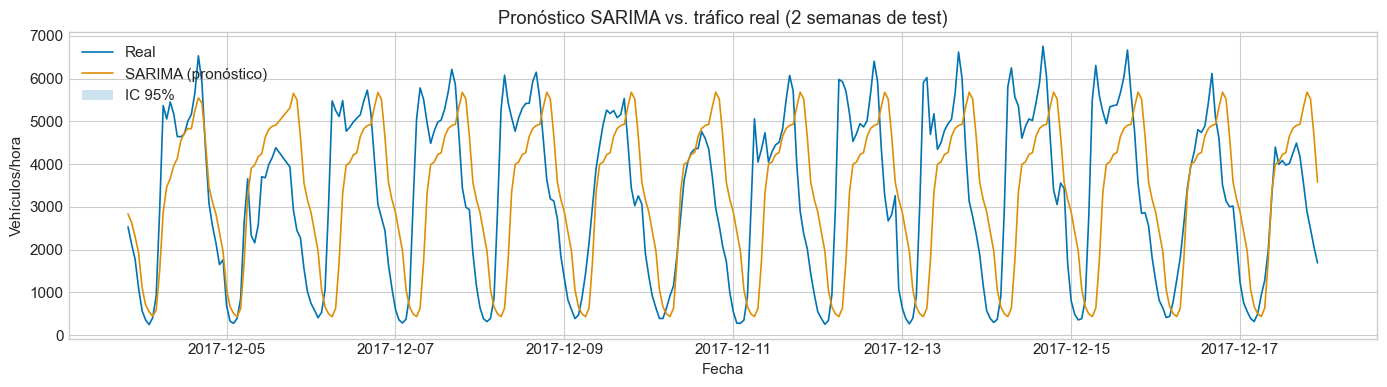

In [8]:
plot_h = min(336, len(y_test))
idx = y_test.index[:plot_h]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, y_test.iloc[:plot_h], label="Real", linewidth=1.2)
ax.plot(idx, sarima_pred.iloc[:plot_h], label="SARIMA (pronóstico)", linewidth=1.2)
ax.fill_between(
    idx,
    sarima_lower.iloc[:plot_h],
    sarima_upper.iloc[:plot_h],
    alpha=0.2,
    label="IC 95%",
)
ax.set_title("Pronóstico SARIMA vs. tráfico real (2 semanas de test)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Vehículos/hora")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones (§3.5)

#### Por qué se hizo así
- Se pronostican **672 pasos** (horizonte test fijado en NB1/NB2) con el `sarima_final` ya elegido — no se re-estima en test (evaluación **out-of-sample** honesta).
- Métricas **MAE, RMSE, MAPE** para comparar con baselines en la misma escala (veh/h).
- Gráfico de 2 semanas + IC 95% para ver **forma** del error, no solo un número.

#### Qué significa evaluar OOS
- In-sample (AIC/BIC) mide ajuste al pasado; **test** mide si el modelo **generaliza** al futuro inmediato (dic 2017).
- RMSE penaliza errores grandes (picos mal predichos); MAE es más robusta; MAPE es relativo y engañoso si hay horas con poco tráfico.

#### Resultados
| Métrica | SARIMA final | Baseline HW |
|---------|--------------|-------------|
| MAE | **1489.3** veh/h | 1512.7 |
| RMSE | **1898.5** veh/h | **1803.7** |
| MAPE | 102.1% | — |
| Δ RMSE vs HW | **+94.8** (peor) | — |

- Gráfico: captura `capturas/notebook_3/Celda 3_5 - Pronóstico SARIMA vs tráfico real.png`.

#### Qué significan los resultados
- **Ciclo diario bien capturado** (subidas/bajadas cada 24 h), pero **picos subestimados** (~500–1000 veh/h de diferencia en horas punta) y curva más **suave** que el real (pierde doble pico rush hour).
- IC 95% **muy angosto** vs error visible → el modelo subestima incertidumbre; intervalos poco útiles para planificación conservadora.
- MAE ligeramente mejor que HW, pero **RMSE peor** → SARIMA falla más en **días/horas extremos** (exactamente donde RMSE castiga).
- **Conclusión:** el SARIMA$(2,1,2)(1,1,1)_{24}$ **no justifica** reemplazar al HW amortiguado en este horizonte; la estacionalidad determinística + amortiguamiento de ETS ya resuelve gran parte del problema.

## 3.6 - Diagnóstico SARIMA

En esta sección se analizan los **residuos** del SARIMA final: gráficos, ACF, Q-Q y test de **Ljung-Box**.

**Motivación:** un SARIMA adecuado deja residuos aproximadamente **ruido blanco**. Autocorrelación residual indica especificación incompleta.

**Procedimiento:** residuos in-sample; Ljung-Box en lags 24 y 48 ($H_0$: ruido blanco; $p<0{,}05$ → rechazo); ACF y Q-Q.

**Resultado esperado:** gráficos de diagnóstico (ver `capturas/notebook_3/Celda 3_6 - diagnóstico SARIMA.png`) y tabla Ljung-Box impresa.

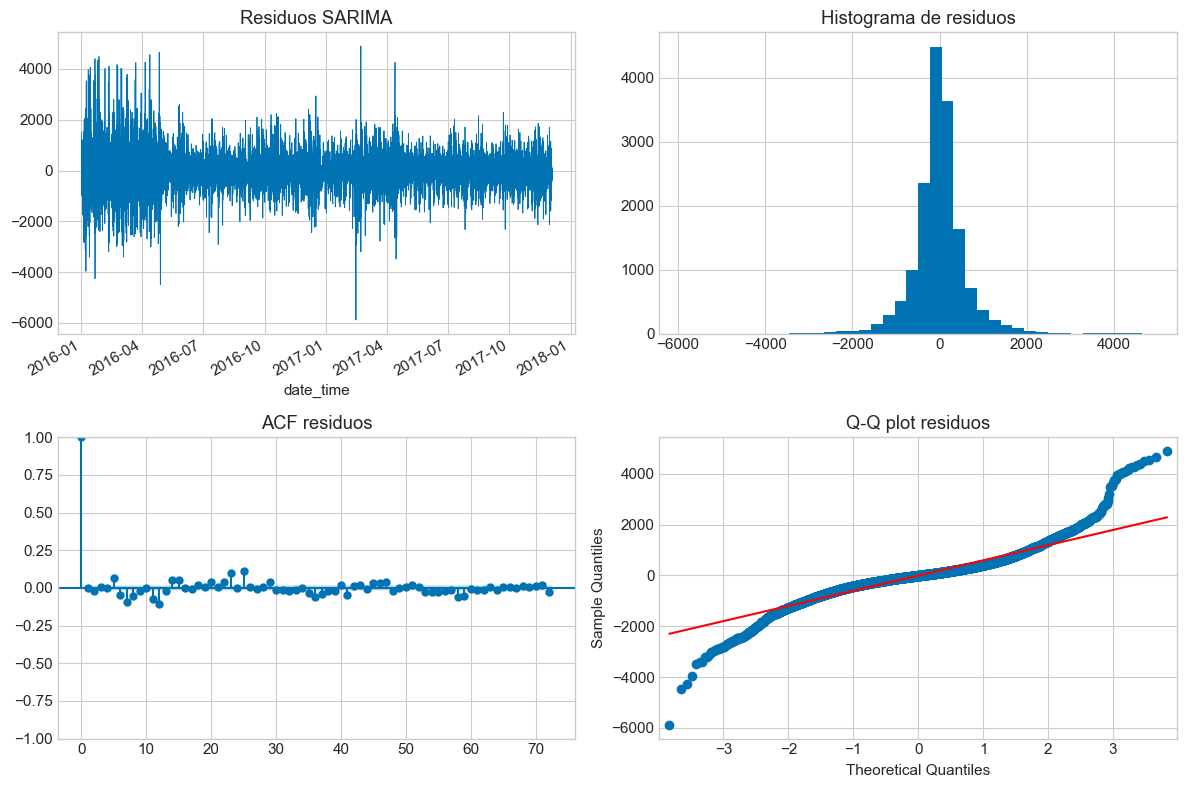

Ljung-Box — residuos SARIMA:
      lb_stat  lb_pvalue
24   885.7156        0.0
48  1366.7740        0.0


In [9]:
resid_sarima = sarima_final.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
resid_sarima.plot(ax=axes[0, 0], title="Residuos SARIMA", linewidth=0.6)
resid_sarima.hist(bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Histograma de residuos")
plot_acf(resid_sarima, lags=72, ax=axes[1, 0])
axes[1, 0].set_title("ACF residuos")
qqplot(resid_sarima, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q plot residuos")
plt.tight_layout()
plt.show()

ljung_sarima = acorr_ljungbox(resid_sarima, lags=[24, 48], return_df=True)
print("Ljung-Box — residuos SARIMA:")
print(ljung_sarima.round(4))

### Conclusiones (§3.6)

#### Por qué se hizo así
- Tras elegir `sarima_final`, hay que verificar si el modelo **agotó la estructura temporal**: si queda autocorrelación en residuos, la especificación está **incompleta** (aunque pronostique aceptablemente).
- **Ljung-Box** en lags 24 y 48 testea ruido blanco en el horizonte diario y bisíestre de horas; **ACF/Q-Q** dan diagnóstico visual complementario.

#### Qué significa un buen diagnóstico
- **Residuos ≈ ruido blanco:** lo no explicado por el modelo parece aleatorio → confianza en que no falta un lag obvio.
- **$p$-valor Ljung-Box:** bajo $H_0$ = “no hay autocorrelación hasta el lag $h$”. $p < 0{,}05$ → **rechazamos** ruido blanco (mal diagnóstico). $p > 0{,}05$ → no hay evidencia contra ruido blanco (bueno).

#### Resultados
- **Ljung-Box SARIMA:** lag 24 → stat ≈ 886, **$p \approx 0$**; lag 48 → stat ≈ 1367, **$p \approx 0$**.
- **ACF residuos:** barras mayormente dentro de ±0,1 (sin pico aislado en 24 h).
- **Q-Q / histograma:** colas pesadas; residuos no normales (outliers ±4000–6000 veh/h).
- Captura: `capturas/notebook_3/Celda 3_6 - diagnóstico SARIMA.png`.

#### Qué significan los resultados
- **Ljung-Box rechaza** ruido blanco → queda estructura temporal sin modelar (estacionalidad semanal con $s=24$ fijo, huecos horarios, clima, efectos de fin de semana distintos).
- **Paradoja ACF vs Ljung-Box:** la ACF puede verse “plana” lag a lag, pero Ljung-Box resume **muchos** lags; una autocorrelación **débil pero persistente** en muchos lags basta para rechazar $H_0$.
- **No normalidad:** errores extremos más frecuentes que en una campana → IC gaussianos subestiman riesgo de eventos raros.
- **Decisión:** el SARIMA univariado está **mal especificado** en sentido estricto, pero igual se avanza a SARIMAX (§3.7) para ver si exógenas absorben parte del residuo y mejoran pronóstico.

## 3.7 - SARIMAX

En esta sección se ajusta **SARIMAX** incorporando exógenas: `temp` (Kelvin), `rain_1h`, `snow_1h`, `is_holiday`.

**Motivación:** responder si variables meteorológicas y feriados mejoran el pronóstico frente al SARIMA univariado (pregunta central del TP).

**Procedimiento:** mismos órdenes que `sarima_final`; `exog=X_train` en ajuste; `exog=X_test` en pronóstico (**valores observados**).

**Resultado esperado:** modelo `sarimax_final` con summary de coeficientes exógenos.

In [10]:
sarimax_final = SARIMAX(
    y_train,
    exog=X_train,
    order=final_order,
    seasonal_order=final_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(sarimax_final.summary())

                                      SARIMAX Results                                       
Dep. Variable:                       traffic_volume   No. Observations:                15879
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood             -124531.583
Date:                              Sun, 14 Jun 2026   AIC                         249085.166
Time:                                      19:39:20   BIC                         249169.530
Sample:                                           0   HQIC                        249113.083
                                            - 15879                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp          63.4814      4.884     12.997      0.000      53.908      73.055
rain_1h       -0.26

In [11]:
fc_sarimax = sarimax_final.get_forecast(steps=len(y_test), exog=X_test)
fc_sarimax_frame = fc_sarimax.summary_frame()
sarimax_pred = pd.Series(fc_sarimax_frame["mean"].values, index=y_test.index)
sarimax_lower = pd.Series(fc_sarimax_frame["mean_ci_lower"].values, index=y_test.index)
sarimax_upper = pd.Series(fc_sarimax_frame["mean_ci_upper"].values, index=y_test.index)

mae_x, rmse_x, mape_x = eval_metrics(y_test.values, sarimax_pred.values)
print(f"SARIMAX — MAE: {mae_x:.1f} | RMSE: {rmse_x:.1f} | MAPE: {mape_x:.1f}%")

SARIMAX — MAE: 1410.9 | RMSE: 1854.8 | MAPE: 80.2%


### Conclusiones (§3.7)

#### Por qué se hizo así
- Pregunta central del TP: ¿**clima y feriados** mejoran el pronóstico frente al SARIMA univariado?
- Se mantienen los **mismos órdenes** que `sarima_final` $(2,1,2)(1,1,1)_{24}$: solo se agrega información exógena, sin re-identificar ARIMA (aisla el efecto de las $X$).
- Exógenas en test = **valores observados** (limitación: en producción habría que pronosticar el clima primero).

#### Qué significa un SARIMAX aquí
- La parte SARIMA captura **inercia y estacionalidad** del tráfico; las exógenas capturan **shocks explicados por clima/feriado** que se repiten condicionalmente a la hora del día.
- Coeficiente $\beta$ de `rain_1h`: cambio esperado en veh/h por +1 mm de lluvia, **manteniendo fija** la dinámica ARIMA.

#### Resultados
- **In-sample:** AIC **249.085**, BIC **249.170** (mejor que SARIMA univariado).
- **OOS test:** MAE **1410.9**, RMSE **1854.8**, MAPE **80.2%**.
- Coeficientes ($H_0\!: \beta=0$, $\alpha=0{,}05$):
  - `rain_1h` **−0,26** ($p<0{,}001$) ✓
  - `temp` **+63,5 K** ($p<0{,}001$)
  - `snow_1h` **+2865** ($p=0{,}0003$)
  - `is_holiday` **+27,0** ($p=0{,}888$, n.s.)

#### Qué significan los resultados
- **Lluvia:** significativa y con signo esperado — menos tráfico con más lluvia; magnitud pequeña (~0,26 veh/h por mm) pero detectable por el gran $n$.
- **Temperatura positiva:** no leer como “más calor → más tráfico” de forma causal; **confunde estación** (verano = calor + más volumen). El SARIMA ya modela el ciclo diario, pero no separa estación anual de temperatura.
- **Nieve positiva:** artefacto de **pocos eventos** y días atípicos; coeficiente inestable pese a $p$ bajo.
- **Feriado n.s.:** el efecto feriado queda **absorbido** por la estacionalidad SARIMA (patrón distinto los fines de semana/feriados ya parcialmente capturado).
- **OOS:** mejora ~44 veh/h RMSE vs SARIMA, pero **1854.8 > 1803.7** (HW) — clima ayuda, pero **no alcanza** al mejor baseline.

## 3.8 - Comparación SARIMA vs SARIMAX

En esta sección se contrastan SARIMA y SARIMAX en criterios in-sample (AIC, BIC, LLH) y out-of-sample (MAE, RMSE, MAPE).

**Motivación:** determinar objetivamente si las exógenas aportan capacidad predictiva adicional.

**Resultado esperado:** tabla comparativa y designación del **modelo final** para export y NB4.

In [12]:
compare_sarimax = pd.DataFrame(
    [
        {
            "modelo": "SARIMA",
            "AIC": sarima_final.aic,
            "BIC": sarima_final.bic,
            "LLH": sarima_final.llf,
            "MAE_test": mae_s,
            "RMSE_test": rmse_s,
            "MAPE_test": mape_s,
        },
        {
            "modelo": "SARIMAX",
            "AIC": sarimax_final.aic,
            "BIC": sarimax_final.bic,
            "LLH": sarimax_final.llf,
            "MAE_test": mae_x,
            "RMSE_test": rmse_x,
            "MAPE_test": mape_x,
        },
    ]
)

print("Comparación SARIMA vs SARIMAX:")
print(compare_sarimax.round(3).to_string(index=False))

if rmse_x < rmse_s:
    model_final = sarimax_final
    model_final_name = "SARIMAX"
    y_pred_final = sarimax_pred
else:
    model_final = sarima_final
    model_final_name = "SARIMA"
    y_pred_final = sarima_pred

print(f"\nModelo final por RMSE test: {model_final_name}")

Comparación SARIMA vs SARIMAX:
 modelo        AIC        BIC         LLH  MAE_test  RMSE_test  MAPE_test
 SARIMA 249174.125 249227.811 -124580.063  1489.311   1898.470    102.132
SARIMAX 249085.166 249169.530 -124531.583  1410.938   1854.762     80.237

Modelo final por RMSE test: SARIMAX


### Conclusiones (§3.8)

#### Por qué se hizo así
- Hay que decidir el **modelo final** del notebook con criterio explícito: **RMSE en test** (métrica operativa del TP), complementado con AIC/BIC in-sample.
- Se contrastan **SARIMA** y **SARIMAX** en la misma tabla para responder: ¿vale la pena la complejidad extra de exógenas?

#### Qué significa la comparación dual
- **In-sample (AIC/BIC):** ¿cuál explica mejor el pasado?
- **Out-of-sample (RMSE test):** ¿cuál predice mejor el futuro? — **más relevante** para el informe final.
- Un modelo puede ganar in-sample y perder test (sobreajuste); aquí SARIMAX gana en **ambos**.

#### Resultados
| | SARIMA | SARIMAX |
|---|--------|---------|
| AIC | 249.174 | **249.085** |
| BIC | 249.228 | **249.170** |
| MAE test | 1489.3 | **1410.9** |
| RMSE test | 1898.5 | **1854.8** |
| MAPE test | 102.1% | **80.2%** |

- **`model_final` = SARIMAX** (menor RMSE test).
- vs HW baseline: RMSE **1854.8** vs **1803.7** (SARIMAX aún **+51** veh/h peor).

#### Qué significan los resultados
- **Dentro de Box-Jenkins:** SARIMAX es claramente superior — clima aporta señal predictiva incremental (~44 veh/h RMSE).
- **Frente al TP completo:** HW amortiguado **sigue ganando** — métodos clásicos con estacionalidad determinística + amortiguamiento superan ARIMA en este dataset y horizonte.
- **Para vos:** ganar in-sample no basta; la pregunta operativa es test. Y el **mejor modelo global** puede ser un baseline simple, no el más sofisticado.

## 3.9 - Interpretación de coeficientes exógenos

En esta sección se interpretan los coeficientes del SARIMAX desde el **sentido físico** esperado en tráfico urbano.

**Hipótesis previas (a contrastar con la estimación):**
- `rain_1h`, `snow_1h` → coeficientes **negativos** (menos vehículos con precipitación).
- `is_holiday` → **negativo** (menos tráfico laboral/comercial).
- `temp` (Kelvin) → efecto ambiguo; correlación lineal ≈ 0,13 en NB1.

**Resultado obtenido:** ver tabla impresa y §3.7; §3.9 sintetiza signos, magnitudes y significancia.

In [13]:
params = sarimax_final.params
pvalues = sarimax_final.pvalues

exog_param_names = [name for name in params.index if any(c in name for c in EXOG_COLS)]
rows_coef = []
for name in exog_param_names:
    rows_coef.append(
        {
            "parametro": name,
            "coef": params[name],
            "p_valor": pvalues[name],
            "significativo_5pct": pvalues[name] < 0.05,
        }
    )

coef_exog = pd.DataFrame(rows_coef)
print(coef_exog.round(4).to_string(index=False))

 parametro      coef  p_valor  significativo_5pct
      temp   63.4814   0.0000                True
   rain_1h   -0.2604   0.0000                True
   snow_1h 2865.2870   0.0003                True
is_holiday   27.0175   0.8875               False


### Conclusiones (§3.9)

#### Por qué se hizo así
- Los coeficientes del §3.7 son **estadísticos**; acá se contrastan con **hipótesis físicas** (lluvia/nieve reducen tráfico, feriado reduce tráfico laboral).
- Separar **significancia** ($p$-valor) de **magnitud** (tamaño de $\beta$) y de **sentido causal** evita sobreinterpretar el summary.

#### Qué significa interpretar un coeficiente exógeno
- $\beta$ = efecto marginal **lineal** de $X$ sobre veh/h, **condicionado** a que la parte SARIMA ya absorbió la dinámica temporal.
- $p < 0{,}05$: evidencia de que $\beta \neq 0$ (no demuestra causalidad ni importancia práctica).
- $p > 0{,}05$: **no hay evidencia** de efecto marginal; no prueba que el efecto sea exactamente cero.

#### Resultados vs hipótesis
| Variable | Coef. | $p$ | ¿Signif.? | ¿Coincide con hipótesis? |
|----------|-------|-----|-----------|--------------------------|
| `rain_1h` | −0,26 | <0,001 | Sí | **Sí** (menos tráfico con lluvia) |
| `temp` | +63,5 K | <0,001 | Sí | **No** (esperábamos débil/ambiguo; sale positivo) |
| `snow_1h` | +2865 | 0,0003 | Sí | **No** (esperábamos negativo) |
| `is_holiday` | +27 | 0,888 | No | Indeterminado (hipótesis: negativo) |

#### Qué significan los resultados
- **Lluvia:** único exógeno con signo, significancia y lectura física **coherentes**; efecto pequeño pero real en promedio.
- **Temperatura:** significativa por **confusión estacional** — en Kelvin, +1 K no “causa” +63 veh/h; es proxy de verano/invierno no capturado del todo por $s=24$.
- **Nieve:** significativa por **escasez de datos** (pocos mm de nieve); signo positivo probablemente refleja días invernales atípicos, no “más nieve → más autos”.
- **Feriado:** sin evidencia marginal lineal; feriados en Minnesota pueden parecerse a patrones de fin de semana ya modelados por SARIMA.
- **Lección general:** coeficiente significativo $\neq$ variable importante para pronosticar; la mejora OOS fue **modesta** (+44 veh/h RMSE vs SARIMA).

## 3.10 - Diagnóstico final y export

En esta sección se diagnostica el **modelo final**, se exportan pronósticos y métricas para NB4.

**Archivos generados:**
- `dataset/results/metricas_modelos.csv` — append filas SARIMA y SARIMAX.
- `dataset/results/sarima_orders_final.json` — órdenes del SARIMA seleccionado.
- `dataset/results/forecasts/sarima_test.csv`, `sarimax_test.csv` — pronósticos test con IC.
- `dataset/results/coeficientes_sarimax.csv` — coeficientes exógenos.

In [14]:
resid_final = model_final.resid.dropna()
ljung_final = acorr_ljungbox(resid_final, lags=[24, 48], return_df=True)
print(f"Ljung-Box — residuos {model_final_name}:")
print(ljung_final.round(4))

Ljung-Box — residuos SARIMAX:
      lb_stat  lb_pvalue
24   711.6883        0.0
48  1148.0906        0.0


In [15]:
# Pronósticos test
forecast_sarima = pd.DataFrame(
    {
        "date_time": y_test.index,
        "y_real": y_test.values,
        "y_pred": sarima_pred.values,
        "ic_lower": sarima_lower.values,
        "ic_upper": sarima_upper.values,
    }
)
forecast_sarimax = pd.DataFrame(
    {
        "date_time": y_test.index,
        "y_real": y_test.values,
        "y_pred": sarimax_pred.values,
        "ic_lower": sarimax_lower.values,
        "ic_upper": sarimax_upper.values,
    }
)

sarima_fc_path = FORECASTS_DIR / "sarima_test.csv"
sarimax_fc_path = FORECASTS_DIR / "sarimax_test.csv"
forecast_sarima.to_csv(sarima_fc_path, index=False)
forecast_sarimax.to_csv(sarimax_fc_path, index=False)

# Métricas: append a NB2
new_metrics = pd.DataFrame(
    [
        {
            "modelo": f"SARIMA{final_order}x{final_seasonal_order}",
            "MAE": mae_s,
            "RMSE": rmse_s,
            "MAPE": mape_s,
        },
        {
            "modelo": "SARIMAX",
            "MAE": mae_x,
            "RMSE": rmse_x,
            "MAPE": mape_x,
        },
    ]
)
metrics_all = pd.concat([metrics_baselines, new_metrics], ignore_index=True)
metrics_path = RESULTS_DIR / "metricas_modelos.csv"
metrics_all.to_csv(metrics_path, index=False)

# Órdenes finales
sarima_orders_final = {
    "order": list(final_order),
    "seasonal_order": list(final_seasonal_order),
    "s": SEASONAL_PERIOD,
    "seleccion": "manual vs auto_arima por BIC",
    "modelo_final_test": model_final_name,
}
orders_final_path = RESULTS_DIR / "sarima_orders_final.json"
with open(orders_final_path, "w", encoding="utf-8") as f:
    json.dump(sarima_orders_final, f, indent=2)

coef_path = RESULTS_DIR / "coeficientes_sarimax.csv"
coef_exog.to_csv(coef_path, index=False)

print(f"Guardado: {metrics_path}")
print(f"Guardado: {orders_final_path}")
print(f"Guardado: {sarima_fc_path}")
print(f"Guardado: {sarimax_fc_path}")
print(f"Guardado: {coef_path}")

Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\metricas_modelos.csv
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\sarima_orders_final.json
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\forecasts\sarima_test.csv
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\forecasts\sarimax_test.csv
Guardado: C:\fiuba\CEIA-AST\TPs\TP-02\dataset\results\coeficientes_sarimax.csv


**Cierre de la fase SARIMA/SARIMAX:**

- [x] SARIMA manual y grid stepwise comparados; `sarima_final` = **SARIMA$(2,1,2)(1,1,1)_{24}$** (§3.4).
- [x] Pronóstico test con IC 95% y métricas OOS calculadas (§3.5).
- [x] Diagnóstico de residuos (Ljung-Box) del SARIMA y del modelo final (§3.6, §3.10).
- [x] SARIMAX ajustado con exógenas; comparación vs SARIMA documentada (§3.8).
- [x] Coeficientes exógenos interpretados (§3.9).
- [x] Artefactos exportados para NB4 (`metricas_modelos.csv`, pronósticos, órdenes finales).

**Limitaciones:** huecos horarios (~993 h); exógenas observadas en test; estacionalidad semanal no modelada con $s=24$ fijo; SARIMA/SARIMAX no superan RMSE del HW amortiguado (1803.7 veh/h).

### Conclusiones (§3.10)

#### Por qué se hizo así
- Repetir **Ljung-Box** sobre el **modelo final** (SARIMAX) para ver si las exógenas mejoraron el diagnóstico de residuos, no solo el RMSE.
- **Exportar** pronósticos, métricas y órdenes para NB4 (comparación global con HW, ETS, Prophet).

#### Qué significa cerrar la fase
- NB3 responde: (1) ¿qué órdenes SARIMA? → $(2,1,2)(1,1,1)_{24}$; (2) ¿clima ayuda? → sí **vs SARIMA**, no **vs HW**; (3) ¿modelo final Box-Jenkins? → **SARIMAX**.

#### Resultados
- **Modelo final:** SARIMAX, RMSE test **1854.8** veh/h.
- **Ljung-Box residuos SARIMAX:** lag 24 stat ≈ **712**, lag 48 ≈ **1148**, **$p \approx 0$** (mejora vs SARIMA 886/1367, pero sigue rechazando ruido blanco).
- **Exportados:** `metricas_modelos.csv`, `sarima_orders_final.json`, `forecasts/sarima_test.csv`, `forecasts/sarimax_test.csv`, `coeficientes_sarimax.csv`.

#### Qué significan los resultados
- **Ljung-Box aún rechaza** $H_0$ → ni SARIMA ni SARIMAX logran residuos blancos; queda estructura (semanal, huecos, no linealidad) sin modelar. Para el TP: **documentar** el fallo, no ignorarlo.
- **Ranking parcial hasta NB3:** HW (**1803.7**) > SARIMAX (**1854.8**) > SARIMA (**1898.5**) en RMSE test.
- **Para vos — hilo narrativo del notebook:**
  1. NB2 sugirió $(1,1,1)(1,1,1)_{24}$ por ACF/PACF → **punto de partida razonable**.
  2. Grid + BIC eligieron $(2,1,2)(1,1,1)_{24}$ → **los datos pidieron más memoria de corto plazo**.
  3. SARIMA OOS no vence HW → **complejidad ARIMA no se traduce en mejor pronóstico aquí**.
  4. SARIMAX mejora SARIMA → **clima tiene señal**, pero insuficiente para superar un ETS bien afinado.
  5. NB4 decidirá si Prophet u otro modelo cierra la brecha con HW.